# Лабораторная работа 5: Random Forest (career-con-2019)

**Обновленное ТЗ:**
- Разрешено использовать готовую реализацию из `scikit-learn`.

**Задание:**
- Использовать датасет `career-con-2019`.
- Обучить `RandomForestClassifier`.
- Обосновать ограничение глубины дерева (`max_depth`).
- Посчитать `accuracy`, `precision`, `recall`, `F1`.
- Вывести ROC-кривую.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

np.random.seed(42)

## 1) Загрузка данных

В датасете каждый объект `series_id` состоит из 128 измерений сенсоров.
Для классификации поверхности агрегируем временной ряд в табличные признаки.

In [7]:
base_dir = Path('career-con-2019')
X_train_path = base_dir / 'X_train.csv'
y_train_path = base_dir / 'y_train.csv'

if not X_train_path.exists() or not y_train_path.exists():
    raise FileNotFoundError('Не найдены career-con-2019/X_train.csv и/или y_train.csv')

X_raw = pd.read_csv(X_train_path)
y_raw = pd.read_csv(y_train_path)

print('X_raw shape:', X_raw.shape)
print('y_raw shape:', y_raw.shape)
print('Число классов:', y_raw['surface'].nunique())
y_raw['surface'].value_counts()

X_raw shape: (487680, 13)
y_raw shape: (3810, 3)
Число классов: 9


surface
concrete                  779
soft_pvc                  732
wood                      607
tiled                     514
fine_concrete             363
hard_tiles_large_space    308
soft_tiles                297
carpet                    189
hard_tiles                 21
Name: count, dtype: int64

## 2) Подготовка признаков

Исключаем служебные поля и агрегируем признаки по `series_id`: `mean`, `std`, `min`, `max`, `median`, `q25`, `q75`.

In [8]:
drop_cols = ['row_id', 'measurement_number']
sensor_cols = [c for c in X_raw.columns if c not in drop_cols + ['series_id']]

grouped = X_raw.groupby('series_id')[sensor_cols]
X_stat = grouped.agg(['mean', 'std', 'min', 'max', 'median'])
q25 = grouped.quantile(0.25).add_suffix('_q25')
q75 = grouped.quantile(0.75).add_suffix('_q75')

X_stat.columns = [f'{c[0]}_{c[1]}' for c in X_stat.columns]
X_feat = X_stat.join(q25).join(q75).fillna(0.0)

y_series = y_raw[['series_id', 'surface']].set_index('series_id').loc[X_feat.index, 'surface']

classes = sorted(y_series.unique())
cls_to_id = {c: i for i, c in enumerate(classes)}
id_to_cls = {i: c for c, i in cls_to_id.items()}

X = X_feat.to_numpy(dtype=float)
y = np.array([cls_to_id[v] for v in y_series.to_numpy()])

print('Матрица признаков:', X.shape)
print('Классы:', classes)

Матрица признаков: (3810, 70)
Классы: ['carpet', 'concrete', 'fine_concrete', 'hard_tiles', 'hard_tiles_large_space', 'soft_pvc', 'soft_tiles', 'tiled', 'wood']


## 3) Модель Random Forest из `scikit-learn`

Используем `RandomForestClassifier`.

Комментарий по формулировке про дерево в лесу:
- в реализации `sklearn` базовые деревья (`DecisionTreeClassifier`) строят **бинарные сплиты**;
- при этом дерево обычно **не сбалансировано**: глубина ветвей различается, так как разбиения зависят от данных.

Ограничение `max_depth` обосновываем через валидацию: слишком большая глубина повышает риск переобучения, поэтому выбираем глубину с лучшим качеством на валидации (по `F1 weighted`).

In [9]:
# Разделение данных (стратифицированно по классам)
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Подбор max_depth по валидации (только ограниченные значения глубины)
candidate_depths = [6, 8, 10, 12, 14, 16]
cv_rows = []

for depth in candidate_depths:
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    cv_rows.append({
        'max_depth': depth,
        'f1_weighted': f1_score(y_valid, pred, average='weighted')
    })

# Для display используем DataFrame, лучший depth выбираем по максимуму F1.
depth_df = pd.DataFrame(cv_rows).sort_values('f1_weighted', ascending=False)
display(depth_df)

best_row = max(cv_rows, key=lambda row: row['f1_weighted'])
best_depth = best_row['max_depth']
print('Выбранный max_depth:', best_depth)

,max_depth,f1_weighted
4,14,0.864386
5,16,0.861719
3,12,0.852519
2,10,0.834916
1,8,0.792555
0,6,0.720190


Выбранный max_depth: 14


## 4) Обучение финальной модели

По результатам валидации фиксируем `max_depth = best_depth`.

Обоснование ограничения глубины:
- без ограничения дерево в ансамбле может расти до почти чистых листьев и переобучаться;
- при ограничении глубины уменьшается дисперсия модели и улучшается перенос на отложенную выборку;
- конкретное значение выбрано эмпирически по лучшему `F1 weighted` на валидации.

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=best_depth,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_valid)
y_proba = rf.predict_proba(X_valid)

print('Train size:', X_train.shape)
print('Valid size:', X_valid.shape)
print('Classes:', len(classes))

Train size: (3048, 70)
Valid size: (762, 70)
Classes: 9


## 5) Метрики качества: Accuracy, Precision, Recall, F1

In [11]:
acc = accuracy_score(y_valid, y_pred)
prec = precision_score(y_valid, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_valid, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_valid, y_pred, average='weighted', zero_division=0)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')

Accuracy : 0.8648
Precision: 0.8674
Recall   : 0.8648
F1-score : 0.8644


## 6) ROC-кривые (One-vs-Rest)

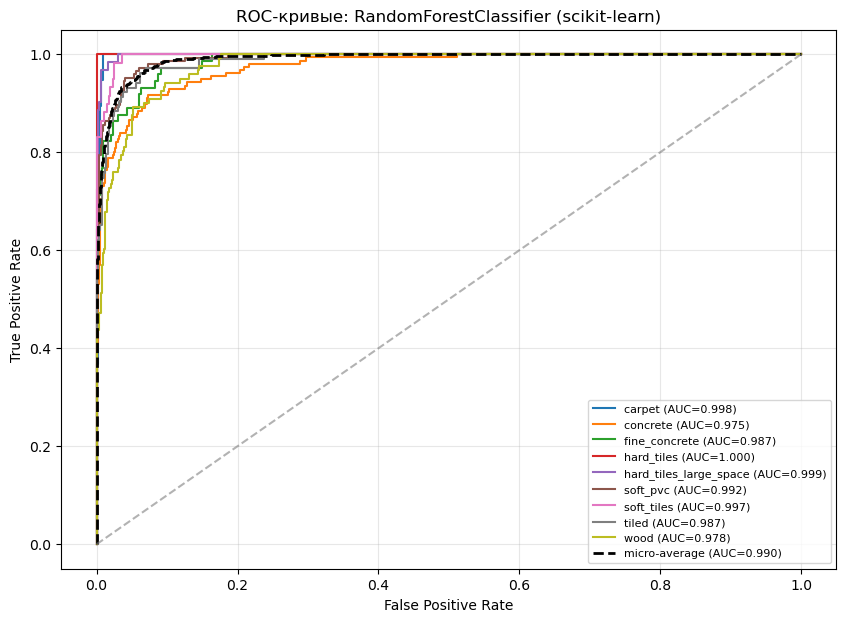

In [12]:
n_classes = len(classes)
y_valid_bin = label_binarize(y_valid, classes=np.arange(n_classes))

fpr = {}
tpr = {}
roc_auc = {}

for c in range(n_classes):
    fpr[c], tpr[c], _ = roc_curve(y_valid_bin[:, c], y_proba[:, c])
    roc_auc[c] = auc(fpr[c], tpr[c])

fpr_micro, tpr_micro, _ = roc_curve(y_valid_bin.ravel(), y_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.figure(figsize=(10, 7))
for c in range(n_classes):
    plt.plot(fpr[c], tpr[c], lw=1.5, label=f'{id_to_cls[c]} (AUC={roc_auc[c]:.3f})')

plt.plot(fpr_micro, tpr_micro, 'k--', lw=2, label=f'micro-average (AUC={roc_auc_micro:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: RandomForestClassifier (scikit-learn)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.show()

## 7) Краткий вывод

- Лабораторная приведена к обновленному ТЗ: использован `RandomForestClassifier` из `scikit-learn`.
- В ансамбле используются деревья с бинарными разбиениями, но они не обязаны быть сбалансированными по форме.
- Ограничение `max_depth` выбрано по валидации как регуляризация против переобучения.
- Рассчитаны `accuracy`, `precision`, `recall`, `F1`, построены ROC-кривые в схеме One-vs-Rest.